In [392]:
import pandas as pd                             # pandas
import numpy as np                              # numpy
import matplotlib.pyplot as plt                 # matplotlib
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # - 깨짐 방지
data1 = pd.read_csv('./kdrama.csv')             # 드라마 데이터 가져오기

In [393]:
# 컬럼명 한글로 변환
data1 = data1.rename(columns={
    "Name": "작품명","Aired Date": "방영 기간","Year of release": "공개 연도","Original Network": "원작 방송사","Aired On": "방영 요일"
    , "Number of Episodes": "총 에피 수","Duration": "회당 러닝타임","Content Rating": "시청 등급", "Rating": "평점","Synopsis": "줄거리"
    , "Genre": "장르","Tags": "태그","Director": "감독","Screenwriter": "각본","Cast": "출연진","Production companies": "제작사","Rank": "순위"
})
# 전체 장르명 한글로 변환해줄 딕셔너리
genre_kr = {
    'Romance': '로맨스','Drama': '드라마','Mystery': '미스터리','Comedy': '코미디','Thriller': '스릴러','Life': '일상','Action': '액션'
    ,'Melodrama': '멜로드라마','Historical': '사극','Fantasy': '판타지','Law': '법정','Crime': '범죄','Supernatural': '초자연','Psychological': '심리'
    ,'Political': '정치','Youth': '청춘','Medical': '의학','Family': '가족','Horror': '공포','Sci-Fi': 'SF','Friendship': '우정'
    ,'Business': '비즈니스','Sports': '스포츠','Military': '군대','Music': '음악','Adventure': '모험','Food': '음식','School': '학원','Sitcom': '시트콤'
}

def translate_genres(genre_str):
    if pd.isna(genre_str):
        return genre_str

    genres = [g.strip() for g in genre_str.split(',')]
    return ', '.join(genre_kr.get(g, g) for g in genres)

data1['장르'] = data1['장르'].apply(translate_genres)
data1['장르']

0              일상, 드라마, 가족
1      스릴러, 로맨스, 범죄, 멜로드라마
2          우정, 로맨스, 일상, 의학
3          우정, 로맨스, 일상, 의학
4          심리, 일상, 드라마, 가족
              ...         
245       사극, 로맨스, 의학, 판타지
246     사극, 로맨스, 멜로드라마, 정치
247       법정, 로맨스, 일상, 드라마
248      공포, 코미디, 로맨스, 판타지
249      액션, 스릴러, 미스터리, 범죄
Name: 장르, Length: 250, dtype: object

In [394]:
# 필요한 컬럼만 가져와서 DataFrame 새로 만들기
df1 = data1[['작품명', '장르', '공개 연도', '평점', '순위']].copy()
# 2010년 이전의 데이터는 데이터의 크기가 너무 작아 유의미한 의미를 가지지 못할것 같아 2010년 이전 데이터는 전부 제외
df1 = df1[df1['공개 연도'] >= 2010]                                
df1

,작품명,장르,공개 연도,평점,순위
0,Move to Heaven,"일상, 드라마, 가족",2021,9.2,#1
1,Flower of Evil,"스릴러, 로맨스, 범죄, 멜로드라마",2020,9.1,#2
2,Hospital Playlist,"우정, 로맨스, 일상, 의학",2020,9.1,#3
3,Hospital Playlist 2,"우정, 로맨스, 일상, 의학",2021,9.1,#4
4,My Mister,"심리, 일상, 드라마, 가족",2018,9.1,#5
...,...,...,...,...,...
245,Live Up to Your Name,"사극, 로맨스, 의학, 판타지",2017,8.3,#246
246,Queen for Seven Days,"사극, 로맨스, 멜로드라마, 정치",2017,8.3,#247
247,Memory,"법정, 로맨스, 일상, 드라마",2016,8.3,#248
248,A Korean Odyssey,"공포, 코미디, 로맨스, 판타지",2017,8.3,#249


# 가설1. OTT의 출시와 대중화는 장르선호도의 변화를 끼쳤을까? 
## 그룹핑 : OTT 출시전 :  2010–2015 / 넷플릭스 출시 : 2016–2018 / 넷플릭스 대중화 : 2019–2022

In [395]:
ott1 = df1[(df1['공개 연도'] >= 2010) & (df1['공개 연도'] <2016)]   #(10~15년도 데이터만 따로 추출)
ott2 = df1[(df1['공개 연도'] >= 2016) & (df1['공개 연도'] <2018)]   #(10~15년도 데이터만 따로 추출)
ott3 = df1[(df1['공개 연도'] >= 2019)]   #(10~15년도 데이터만 따로 추출)

In [396]:
# 1. 2016년까지의 데이터 문자열로 변환 개행 시켜주는 이스케이프 문자 제거
# 2. ','를 기준으로 분리 3. 공백 제거 4. 몇개인지 세주고
ott1_g = ott1['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ott2_g = ott2['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ott3_g = ott3['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()

In [406]:
# 년도별로 구분해둔 장르의 개수와 평균평점, 선호도를 저장해두는 데이터프레임 모음집 만드는 함수

# 매개변수 df = 시대구분 데이터프레임 / g = 장르의 이름 담아둔 리스트 / store = 데이터 프레임 담아둘 변수 이름 / name = 불러올 키값,구분명
def makeDf(df, g, store, name):
    dic = {}
    for i in g:
        dic[i] = df[df['장르'].str.contains(i)]['평점']

    store[name] = pd.DataFrame({
        '갯수': {genre: len(ratings) for genre, ratings in dic.items()},
        '평균 평점': {genre: ratings.mean() for genre, ratings in dic.items()},
        '선호도': {genre: (ratings.mean() * np.log(len(ratings) + 1)) for genre, ratings in dic.items()}
    })

    store[name]['평균 평점'] = store[name]['평균 평점'].round(2)
    store[name]['선호도'] = store[name]['선호도'].round(2)

    store[name] = store[name].sort_values('선호도', ascending=False)

In [407]:
# 차트 그리는 함수  
def draw_chart(x,y,t):             # 매개변수 x => x축 / y => y축 / t => 차트 제목
    plt.figure(figsize=(12, 6))    # 차트 크기 키우고
    plt.xticks(rotation=45)        # x축의 이름 45도 기울이기 ==> 보기 편하게
    plt.grid(True, linestyle='--', alpha=0.6)     # 점선 넣기
    plt.title(t)
    plt.xlabel("장르")
    plt.ylabel("선호도")
    plt.text(0.65, 0.95,'선호도 = 평균 평점 × log(작품 수 + 1)',
        transform = plt.gca().transAxes,
        fontsize = 13,
        verticalalignment='top')
    plt.bar(x,y)                        # 차트에 x축 y축에 데이터 넣기
    plt.show()                           # 차트 그리기

In [408]:
# 시대별 구분에 따른 데이터프레임 모읍집 생성
summary_store = {}

makeDf(ott1, ott1_g, summary_store, 'OTT출시전')
makeDf(ott2, ott2_g, summary_store, 'OTT출시')
makeDf(ott3, ott3_g, summary_store, 'OTT대중화')

ott1_summary = summary_store['OTT출시전']
ott2_summary = summary_store['OTT출시']
ott3_summary = summary_store['OTT대중화']

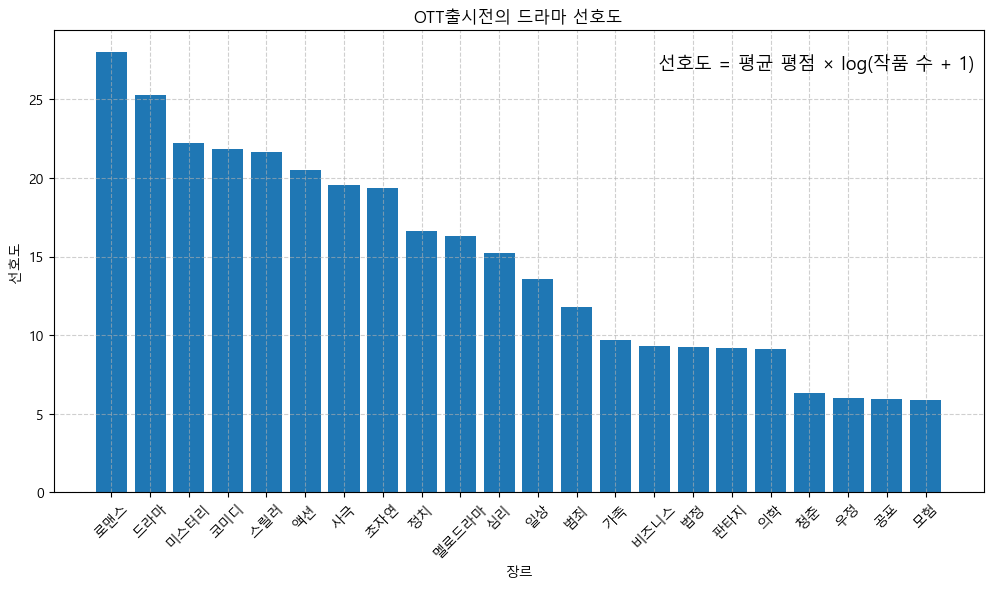

In [409]:
# 드라마의 선호도로 차트 그리기
x1 = ott1_summary.index.tolist()                                  # x축 데이터
y1 = ott1_summary['선호도'].values                              # y축 데이터

draw_chart(x1,y1,'OTT출시전의 드라마 선호도')                  

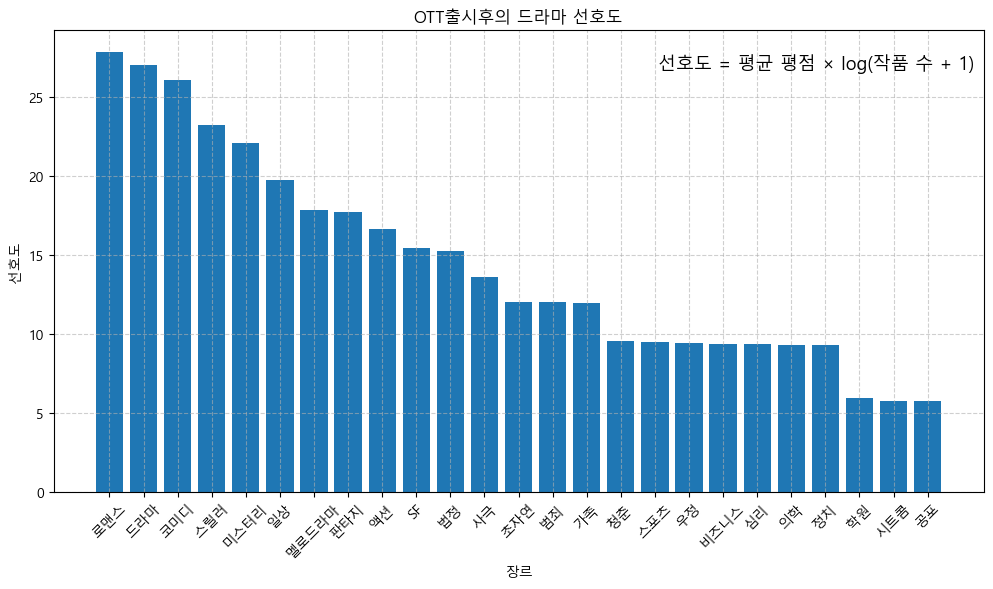

In [410]:
# 드라마의 선호도로 차트 그리기
x2 = ott2_summary.index.tolist()                                  # x축 데이터
y2 = ott2_summary['선호도'].values                              # y축 데이터

draw_chart(x2,y2,'OTT출시후의 드라마 선호도')  

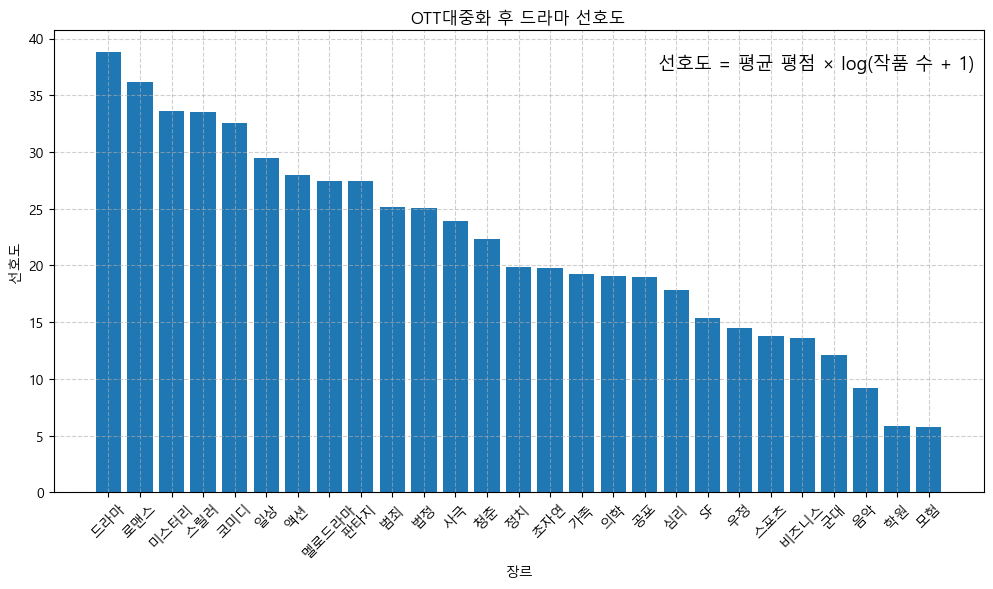

In [411]:
# 드라마의 선호도로 차트 그리기
x3 = ott3_summary.index.tolist()                                  # x축 데이터
y3 = ott3_summary['선호도'].values                              # y축 데이터

draw_chart(x3,y3,'OTT대중화 후 드라마 선호도')  

In [417]:
genre_rank1 = {genre: i+1 for i, genre in enumerate(x1)}
genre_rank2 = {genre: i+1 for i, genre in enumerate(x2)}
genre_rank3 = {genre: i+1 for i, genre in enumerate(x3)}

common_genres = sorted(set(genre_rank1) & set(genre_rank2) & set(genre_rank3))

compare_df = pd.DataFrame({
    '장르': common_genres,
    'OTT 출시전': [genre_rank1[g] for g in common_genres],
    'OTT 출시후': [genre_rank2[g] for g in common_genres],
    'OTT 대중화': [genre_rank3[g] for g in common_genres],
})

compare_df = compare_df.sort_values('OTT 출시전').reset_index(drop=True)

In [418]:
rank_genre1 = {v: k for k, v in genre_rank1.items()}
rank_genre2 = {v: k for k, v in genre_rank2.items()}
rank_genre3 = {v: k for k, v in genre_rank3.items()}

common_ranks = sorted(
    set(rank_genre1) & set(rank_genre2) & set(rank_genre3)
)

compare_df = pd.DataFrame({
    '순위': common_ranks,
    'OTT 출시전': [rank_genre1[r] for r in common_ranks],
    'OTT 출시후': [rank_genre2[r] for r in common_ranks],
    'OTT 대중화': [rank_genre3[r] for r in common_ranks],
})

compare_df = compare_df.set_index('순위')
compare_df

,OTT 출시전,OTT 출시후,OTT 대중화
순위,,,
1,로맨스,로맨스,드라마
2,드라마,드라마,로맨스
3,미스터리,코미디,미스터리
4,코미디,스릴러,스릴러
5,스릴러,미스터리,코미디
6,액션,일상,일상
7,사극,멜로드라마,액션
8,초자연,판타지,멜로드라마
9,정치,액션,판타지


In [413]:
compare_df
horizontal_df = compare_df.T
horizontal_df
df_to_png(horizontal_df, 'ott_genre_rank.png')

In [414]:
genre_rank1 = {genre: i+1 for i, genre in enumerate(x1)}
genre_rank2 = {genre: i+1 for i, genre in enumerate(x2)}
genre_rank3 = {genre: i+1 for i, genre in enumerate(x3)}

common_genres = sorted(set(genre_rank1) & set(genre_rank2) & set(genre_rank3))

compare_df = pd.DataFrame({
    '장르': common_genres,
    'OTT 출시전': [genre_rank1[g] for g in common_genres],
    'OTT 출시후': [genre_rank2[g] for g in common_genres],
    'OTT 대중화': [genre_rank3[g] for g in common_genres],
})

compare_df = compare_df.sort_values('OTT 출시전').reset_index(drop=True)
compare_df

,장르,OTT 출시전,OTT 출시후,OTT 대중화
0,로맨스,1,1,2
1,드라마,2,2,1
2,미스터리,3,5,3
3,코미디,4,3,5
4,스릴러,5,4,4
5,액션,6,9,7
6,사극,7,12,12
7,초자연,8,13,15
8,정치,9,22,14
9,멜로드라마,10,7,8


In [415]:
for i in range(2003,2023):
    print(f"{i}년 : ",data1[(data1['공개 연도'] == i)]['공개 연도'].count())

2003년 :  1
2004년 :  0
2005년 :  0
2006년 :  1
2007년 :  1
2008년 :  0
2009년 :  1
2010년 :  1
2011년 :  4
2012년 :  7
2013년 :  11
2014년 :  7
2015년 :  9
2016년 :  13
2017년 :  27
2018년 :  24
2019년 :  37
2020년 :  35
2021년 :  39
2022년 :  32


In [416]:
genre_count = (
    data1[data1['공개 연도'] > 2005]['장르']
    .str.replace('\r', '', regex=False)   # 개행 문자 제거
    .str.split(',')                        # 쉼표 기준 분리
    .explode()                             # 행으로 펼치기
    .str.strip()                          # 앞뒤 공백 제거
    .value_counts()                       # 카운트
)

genre_count

장르
로맨스      135
드라마      129
미스터리      90
코미디       88
스릴러       86
일상        45
액션        45
멜로드라마     43
판타지       34
사극        33
법정        27
범죄        26
초자연       24
심리        19
정치        18
청춘        17
가족        15
의학        14
공포        11
SF        11
우정         9
비즈니스       9
스포츠        6
군대         4
음악         4
모험         3
학원         2
시트콤        1
음식         1
Name: count, dtype: int64